In [1]:
#SJL 1/2020
#Script to plot the change in surface length for planets with different AM
#Modified from:
#/n/gstore/Labs/Stewart_Lab/slock/Crustal_deformation_despin/Crust_deformation_HERCULES/plot_local_change_surface_rate2.py

###########################################################
###########################################################
###########################################################
import numpy as np
import scipy as sp
import sys
import os
import struct
from scipy import constants as const

#package to use wildcards 
import fnmatch

from scipy.interpolate import LinearNDInterpolator
from scipy.interpolate import griddata

#plotting packages
import matplotlib as mpl
import matplotlib.pyplot as plt
import pylab
import matplotlib.cm as cm
from matplotlib import gridspec


cwd = os.getcwd()
print(cwd)
if sys.platform== 'darwin':
    sys.path.insert(0, cwd+'/Support_scipts')
    print(cwd+'/Support_scripts')
elif (sys.platform== 'win32') | (sys.platform== 'win64'):
    sys.path.insert(0,cwd+"\\Support_scipts")
    
#HERCULES_structures
from HERCULES_structures import *
from surface_size_calc import *
from HERCULES_random_planet_database_structure_1D import *

#functions for calculating non-evenly spaced numerical differentials
from gradients import *

#import colormaps
import colormaps as cmaps
import matplotlib.cm as cm

import svglib.svglib as svglib
svglib.register_font('helvetica', './Helvetica.ttc')

/Users/vq21447/Documents/Lock_2026_SI
/Users/vq21447/Documents/Lock_2026_SI/Support_scripts
CHECK THE LOCATION OF ODYSSEY BACKUP
CHECK THE LOCATION OF ODYSSEY BACKUP


('helvetica', True)

In [2]:
########################################################################################
########################################################################################
########################################################################################
#CONSTANTS
MEarth=5.972E24
LEM=3.5E34
REarth=6.371E6
MMoon=7.34767309E22

aMoon=0.3844E9
aCassini=30*REarth
aRoche=2.9*REarth

#for HERCULES
MEarth_H=5.9879648E24
LEM_H=3.53E34

In [3]:
########################################################################################
########################################################################################
########################################################################################
#PARAMS
Hdir='Earth_correct_params_S3.20c'
Hname='Earth_correct_params_S3.20c'

#flag as to whether to run in plotting mode or whether to redo calculations
flag_calc=1

#AM to compare to
# L_Cassini=(LEM)-(MMoon)*np.sqrt(const.G*aCassini*MEarth)
# L_compare=L_Cassini
# print(L_Cassini/LEM, 0.4*LEM_H/LEM)
# AMref='0.4'

L_present=(LEM)-(MMoon)*np.sqrt(const.G*aMoon*MEarth)
L_compare=L_present
# print(L_present/LEM)
# print(((LEM)-(MMoon)*np.sqrt(const.G*aRoche*MEarth))/LEM)
AMref=str(L_compare/LEM)

#AMref='0.2'

#number of contor lines
Ncont=100
Ncont=10



In [4]:
#AM of Moon at Roche
temp1=(MMoon)*np.sqrt(const.G*2.9*REarth*MEarth)/LEM
temp2=(MMoon)*np.sqrt(const.G*11.8*REarth*MEarth)/LEM

print(temp1, temp2, temp2-temp1)

0.18015542482192784 0.3634037033642536 0.18324827854232575


In [5]:
########################################################################################
########################################################################################
########################################################################################
#MAIN

if flag_calc==1:
    
    Hdatabase=HERCULES_random_planet_database_1D()
    Hdatabase.make_array(Hdir,Hname)
    Hdatabase.initialize_interpolation([0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1],\
                                       [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]], flag_extrap=1)
    
    
    temp_data=Hdatabase.interp_database(L_compare,[0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1],\
                                       [0,0,[0],0,0,0,0,[0],[0],[0],[0],[0],[0],[0],[0],[0],[0],[0]],flag_extrap=1)
    
    temp=np.asarray(temp_data[16])
    
    dl_lat_comp=temp[:,0]
    dl_lon_comp=temp[:,1]
    dA_comp=temp[:,2]

    #######
    #loop over all the HERCULES planets in the directory
    runall=os.listdir(Hdir)
    runlist=[kk for kk in runall if  fnmatch.fnmatch(kk, Hname+'*') ]
    
    #initialize the arrays
    p=[]
    AM=[]
    lat=[]
    DeltaLlon=[]
    DeltaLlat=[]
    DeltaA=[]
    
    #loop over all the runs and find whether they have been successful, failed or have hit the CoRoL
    for k in np.arange(np.size(runlist)):
        #print(runlist[k])
        #find the final output for each AM 
        outall=os.listdir(Hdir+'/'+runlist[k]+'/Output')
        outlist=[x for x in outall if  fnmatch.fnmatch(x, '*final') ]
        
        if np.size(outlist)==0:
            
            print('No final output '+runlist[k])
            p.append([])
        else:
            out=outlist[0]
    
            params=HERCULES_parameters()
            p.append(HERCULES_planet())
            file = open(Hdir+'/'+runlist[k]+'/Output/'+out, "rb")
            params.read_binary(file)
            p[k].read_binary(file)
    
            #see if the run was above or below the CoRoL
            if ((((np.absolute(p[k].Mtot-p[k].Mtot_tar)/p[k].Mtot_tar)>1E-13)\
                     |((np.absolute(p[k].Ltot-p[k].Ltot_tar)/(p[k].Ltot_tar+1))>1E-13))\
                    |((((np.amin(p[k].press)-p[k].pmin)/p[k].pmin)>1E-12)\
                          |(np.absolute((p[k].layers[0].omega-p[k].omega_rot)/(1+p[k].omega_rot))>=1E-12))): #not converged properly or above the CoRoL
                print('Not suitable '+runlist[k])
                
            elif p[k].Ltot<=L_compare:
                DeltaLlon.append(0.0*dl_lat_comp)
                DeltaLlat.append(0.0*dl_lat_comp)
                DeltaA.append(0.0*dl_lat_comp)
                AM.append(p[k].Ltot)
                lat.append(np.arccos(p[k].layers[0].mu)*180/np.pi)
    
            else: #normal exit, corotating body
                #calculate change in lengths
                (dl_lat,dl_lon,dA)=calc_local_length_area(p[k],params,0)
                #(dl_lat_comp,dl_lon_comp,dA_comp)=calc_local_length_area(p_comp,params_comp,0)
    
                #calculate change between two bodies
                #DeltaLlon.append((dl_lon_comp-dl_lon)*(np.pi/180.0))
                DeltaLlon.append((dl_lon_comp-dl_lon)/dl_lon)
    
                #DeltaLlat.append((dl_lat_comp-dl_lat)*(np.pi/180.0))
                DeltaLlat.append((dl_lat_comp-dl_lat)/dl_lat)
    
                #fractional change in local area
                DeltaA.append((dA_comp-dA)/dA)
                
                AM.append(p[k].Ltot)
                
                lat.append(np.arccos(p[k].layers[0].mu)*180/np.pi)
                
                
    #order the results by AM
    ind=np.argsort(AM)
    AM=np.asarray(AM)[ind]
    DeltaLlon=np.asarray(DeltaLlon)[ind]
    DeltaLlat=np.asarray(DeltaLlat)[ind]
    DeltaA=np.asarray(DeltaA)[ind]
    lat=np.asarray(lat)[ind]

Earth_correct_params_S3.20c
	 Earth_correct_params_S3.20c_AM3.3125
	 Earth_correct_params_S3.20c_AM3.30625
	 Earth_correct_params_S3.20c_AM3.325
No final output Earth_correct_params_S3.20c_AM3.4
No final output Earth_correct_params_S3.20c_AM3.5
Not suitable Earth_correct_params_S3.20c_AM3.3125
No final output Earth_correct_params_S3.20c_AM3.35
Not suitable Earth_correct_params_S3.20c_AM3.30625
Not suitable Earth_correct_params_S3.20c_AM3.325


In [6]:
#calculate the interpolation hulls
lat_grid=np.linspace(0, 90, Ncont*(Ncont+1))
AM_grid=np.linspace(float(AMref), np.amax(AM)/LEM,Ncont*(Ncont+1))

LLL, TTT = np.meshgrid(AM_grid, lat_grid)

temp=np.ones(np.shape(lat))
temp=temp*AM[:, None]

DLON=griddata(((temp.flatten()/LEM,90.0-lat.flatten())),DeltaLlon.flatten(),(LLL,TTT))#, method='linear')
DLAT=griddata(((temp.flatten()/LEM,90.0-lat.flatten())),DeltaLlat.flatten(),(LLL,TTT))#, method='linear')
AAA=griddata(((temp.flatten()/LEM,90.0-lat.flatten())),DeltaA.flatten(),(LLL,TTT))#, method='linear')


print('done')

done


/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_91980/1242508325.py:49: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour1 = ax[0][0].contourf(LLL, TTT, DLAT*100, linewidth=1.5, levels=lat_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(lat_contours)-1)))
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_91980/1242508325.py:50: UserWarning: The following kwargs were not used by contour: 'linewidth'
  temp = ax[0][0].contour(LLL, TTT, DLAT*100, linewidth=1.5, levels=[0], colors=['k'])
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_91980/1242508325.py:51: UserWarning: The following kwargs were not used by contour: 'linewidth'
  contour2 = ax[0][1].contourf(LLL, TTT, DLON*100, linewidth=1.5, levels=lon_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(lon_contours)-1)))
/var/folders/mm/ct8d2r3j48bcp_kyghqh_n7r0000gq/T/ipykernel_91980/1242508325.py:52: UserWarning: The following kwargs were not used by contou

3.331437499999993 0.17825658589994117
done


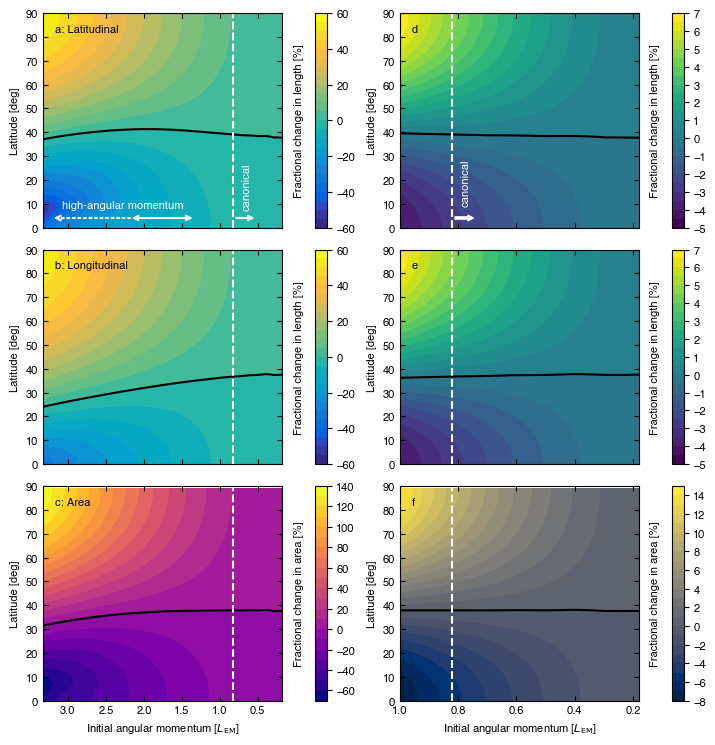

In [72]:

#create a dummy figure figure first to avoid plotting issues
fig = plt.figure(figsize=(7.2,7.5))
font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}
mpl.rc('font', **font)
gs = gridspec.GridSpec(2, 1, height_ratios=[0.64,1])
ax=plt.subplot(gs[0])
ax1=plt.subplot(gs[1])
fig.tight_layout()
plt.savefig('Figure4.pdf')
mpl.pyplot.close(fig)


#####
fig = plt.figure(figsize=(7.2,7.5))
gs = gridspec.GridSpec(3, 2)

ax=[[],[]]
ax_col=[[],[]]

for i in np.arange(3):
    gs2 = gridspec.GridSpecFromSubplotSpec(1,2, subplot_spec = gs[2*i], hspace = .05, width_ratios=[1,0.05])
    ax[0].append(plt.subplot(gs2[0]))
    ax_col[0].append(plt.subplot(gs2[1]))
    
    gs2 = gridspec.GridSpecFromSubplotSpec(1,2, subplot_spec = gs[2*i+1], hspace = .05, width_ratios=[1,0.05])
    ax[1].append(plt.subplot(gs2[0]))
    ax_col[1].append(plt.subplot(gs2[1]))

font = {
'family' : 'Helvetica',
        'weight' : 'normal',
        'size'   : 8}

mpl.rc('font', **font)


lat_contours=np.linspace(-0.6,0.6,24+1)*100
lon_contours=np.linspace(-0.6,0.6,24+1)*100
Acontours=np.linspace(-0.7,1.4,21+1)*100

lat_labels=np.asarray([-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6])*100
lon_labels=np.asarray([-0.6,-0.4,-0.2,0.0,0.2,0.4,0.6])*100
Alabels=np.asarray([-0.6,-0.4,-0.2,0,0.2,0.4,0.6,0.8,1.0,1.2,1.4])*100


contour1 = ax[0][0].contourf(LLL, TTT, DLAT*100, linewidth=1.5, levels=lat_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(lat_contours)-1)))
temp = ax[0][0].contour(LLL, TTT, DLAT*100, linewidth=1.5, levels=[0], colors=['k'])
contour2 = ax[0][1].contourf(LLL, TTT, DLON*100, linewidth=1.5, levels=lon_contours, colors=cmaps.parula_r(np.linspace(1, 0, np.size(lon_contours)-1)))
temp = ax[0][1].contour(LLL, TTT, DLON*100, linewidth=1.5, levels=[0], colors=['k'])
contour3 = ax[0][2].contourf(LLL, TTT, AAA*100, linewidth=1.5, levels=Acontours, colors=cm.plasma(np.linspace(0, 1, np.size(Acontours)-1)))
temp = ax[0][2].contour(LLL, TTT, AAA*100, linewidth=1.5, levels=[0], colors=['k'])

for c in contour1.collections:
    c.set_rasterized(True)
for c in contour2.collections:
    c.set_rasterized(True)
for c in contour3.collections:
    c.set_rasterized(True)
        

#draw lines at Roche limit AM
L_Roche=(LEM)-(MMoon)*np.sqrt(const.G*aRoche*MEarth)
temp=ax[0][0].plot([L_Roche/LEM,L_Roche/LEM], [0,90],'w--',linewidth=1.5)
temp=ax[0][1].plot([L_Roche/LEM,L_Roche/LEM], [0,90],'w--',linewidth=1.5)
temp=ax[0][2].plot([L_Roche/LEM,L_Roche/LEM], [0,90],'w--',linewidth=1.5)

ax[0][0].set_ylabel("Latitude [deg]")
ax[0][1].set_ylabel("Latitude [deg]")
ax[0][2].set_ylabel("Latitude [deg]")
ax[0][2].set_xlabel(r"Initial angular momentum [$L_\mathrm{EM}$]")

for i in np.arange(3):
    if i!=2: plt.setp( ax[0][i].get_xticklabels(), visible=False)
    ax[0][i].tick_params(direction="in", top=True, right=True)

ax[0][0].set_xlim([np.amax(AM)/LEM, float(AMref)])
ax[0][1].set_xlim([np.amax(AM)/LEM, float(AMref)])
ax[0][2].set_xlim([np.amax(AM)/LEM, float(AMref)])


#label axis
ax[0][0].text(0.05, 0.95, 'a: Latitudinal', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][0].transAxes, color='k')
ax[0][1].text(0.05, 0.95, 'b: Longitudinal', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][1].transAxes, color='k')
ax[0][2].text(0.05, 0.95, 'c: Area', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[0][2].transAxes, color='k')

(xmax,xmin)=ax[0][0].get_xlim()
print(xmax, xmin)
ax[0][0].annotate("", xytext=(L_Roche/LEM, 4), xy=(L_Roche/LEM-0.1*(xmax-xmin), 4), arrowprops=dict(arrowstyle="->", lw=1.5,color='w'))
ax[0][0].text(1-(L_Roche/LEM-xmin)/(xmax-xmin)+0.035, 0.08, 'canonical', rotation='vertical', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[0][0].transAxes, color='w')

Llim_impacts=np.asarray([3.4,1.5])-(1-L_Roche/LEM)
Llim_tidal=np.asarray([2.375,1.5])-(1-L_Roche/LEM)
ax[0][0].annotate("",xytext=(Llim_impacts[0], 4),xy=(Llim_impacts[0]-0.12, 4),arrowprops=dict(arrowstyle="<-",color='w',lw=1.5,linestyle="-"))
ax[0][0].annotate("", xytext=(Llim_impacts[0], 4), xy=(Llim_impacts[1], 4), arrowprops=dict(arrowstyle='<->',color='w',lw=1.5,linestyle=":",facecolor="none"))
ax[0][0].annotate("", xytext=(Llim_tidal[0], 4), xy=(Llim_tidal[1], 4), arrowprops=dict(arrowstyle='<->', color='w',lw=1.5,linestyle="-"))
ax[0][0].text(1.055-np.mean(Llim_impacts)/(xmax-xmin), 0.08, 'high-angular momentum', horizontalalignment='center',verticalalignment='bottom', fontsize=8,transform=ax[0][0].transAxes, color='w')


cbar1=plt.colorbar(contour1, cax=ax_col[0][0], orientation='vertical',ticks=lat_labels)
cbar2=plt.colorbar(contour2, cax=ax_col[0][1], orientation='vertical',ticks=lon_labels)
cbar3=plt.colorbar(contour3, cax=ax_col[0][2], orientation='vertical',ticks=Alabels)

cbar1.set_label(r'Fractional change in length [%]', labelpad=-44)
cbar2.set_label(r'Fractional change in length [%]', labelpad=-44)
cbar3.set_label(r'Fractional change in area [%]', labelpad=-44)

#### plot the zoom in
lat_contours=np.linspace(-0.05,0.07,24+1)*100
lon_contours=np.linspace(-0.05,0.07,24+1)*100
Acontours=np.linspace(-0.08,0.15,23+1)*100

lat_labels=np.asarray([-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05,0.06,0.07])*100
lon_labels=np.asarray([-0.05,-0.04,-0.03,-0.02,-0.01,0.0,0.01,0.02,0.03,0.04,0.05,0.06,0.07])*100
Alabels=np.asarray([-0.08,-0.06,-0.04,-0.02,0,0.02,0.04,0.06,0.08,0.1,0.12,0.14])*100

contour1 = ax[1][0].contourf(LLL, TTT, DLAT*100, linewidth=1.5, levels=lat_contours, colors=cm.viridis(np.linspace(0, 1, np.size(lat_contours)-1)))
temp = ax[1][0].contour(LLL, TTT, DLAT*100, linewidth=1.5, levels=[0], colors=['k'])
contour2 = ax[1][1].contourf(LLL, TTT, DLON*100, linewidth=1.5, levels=lon_contours, colors=cm.viridis(np.linspace(0, 1, np.size(lon_contours)-1)))
temp = ax[1][1].contour(LLL, TTT, DLON*100, linewidth=1.5, levels=[0], colors=['k'])
contour3 = ax[1][2].contourf(LLL, TTT, AAA*100, linewidth=1.5, levels=Acontours, colors=cm.cividis(np.linspace(0, 1, np.size(Acontours)-1)))
temp = ax[1][2].contour(LLL, TTT, AAA*100, linewidth=1.5, levels=[0], colors=['k'])

for c in contour1.collections:
    c.set_rasterized(True)
for c in contour2.collections:
    c.set_rasterized(True)
for c in contour3.collections:
    c.set_rasterized(True)

ax[1][0].set_xlim([1.0, float(AMref)])
ax[1][1].set_xlim([1.0, float(AMref)])
ax[1][2].set_xlim([1.0, float(AMref)])

#draw lines at Roche limit AM
temp=ax[1][0].plot([L_Roche/LEM,L_Roche/LEM], [0,90],'w--',linewidth=1.5)
temp=ax[1][1].plot([L_Roche/LEM,L_Roche/LEM], [0,90],'w--',linewidth=1.5)
temp=ax[1][2].plot([L_Roche/LEM,L_Roche/LEM], [0,90],'w--',linewidth=1.5)

#add arrows and line labels
(xmax,xmin)=ax[1][0].get_xlim()
ax[1][0].annotate("", xytext=(L_Roche/LEM, 4), xy=(L_Roche/LEM-0.1*(xmax-xmin), 4), arrowprops=dict(arrowstyle="simple", color='w'))
ax[1][0].text(1-(L_Roche/LEM-xmin)/(xmax-xmin)+0.035, 0.1, 'canonical', rotation='vertical', horizontalalignment='left',verticalalignment='bottom', fontsize=8,transform=ax[1][0].transAxes, color='w')


ax[1][0].set_ylabel("Latitude [deg]")
ax[1][1].set_ylabel("Latitude [deg]")
ax[1][2].set_ylabel("Latitude [deg]")
ax[1][2].set_xlabel(r"Initial angular momentum [$L_\mathrm{EM}$]")

for i in np.arange(3):
    if i!=2: plt.setp( ax[1][i].get_xticklabels(), visible=False)
    ax[1][i].tick_params(direction="in", top=True, right=True)




#label axis
ax[1][0].text(0.05, 0.95, 'd', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[1][0].transAxes, color='k')
ax[1][1].text(0.05, 0.95, 'e', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[1][1].transAxes, color='k')
ax[1][2].text(0.05, 0.95, 'f', horizontalalignment='left',verticalalignment='top', fontsize=8,transform=ax[1][2].transAxes, color='k')

cbar4=plt.colorbar(contour1, cax=ax_col[1][0], orientation='vertical',ticks=lat_labels)
cbar5=plt.colorbar(contour2, cax=ax_col[1][1], orientation='vertical',ticks=lon_labels)
cbar6=plt.colorbar(contour3, cax=ax_col[1][2], orientation='vertical',ticks=Alabels)

cbar4.set_label(r'Fractional change in length [%]', labelpad=-40)
cbar5.set_label(r'Fractional change in length [%]', labelpad=-40)
cbar6.set_label(r'Fractional change in area [%]', labelpad=-40)

fig.tight_layout()
plt.savefig('Figure4.pdf',bbox_inches='tight', dpi=800)

print('done')